In [2]:
# Cell 1: Import libraries and load data
# pandas: loads and manipulates the CSV data
# numpy: numerical calculations
# matplotlib and seaborn: visualisation (charts)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# '../data/' means go one folder up from notebooks/, then into data/
df = pd.read_csv('../data/creditcard.csv')

# Confirm it loaded correctly
print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset loaded successfully
Rows: 284,807
Columns: 31
Memory usage: 67.4 MB


In [3]:
# Cell 2: Data quality check
# Every real project starts with this — never skip it

print("=== DATA TYPES ===")
print(df.dtypes)
print()

print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")
print()

print("=== BASIC STATISTICS ===")
print(df[['Time', 'Amount', 'Class']].describe())
print()

print("=== CLASS DISTRIBUTION ===")
fraud = df['Class'].sum()
legit = (df['Class'] == 0).sum()
total = len(df)
print(f"Legitimate transactions: {legit:,}  ({legit/total*100:.2f}%)")
print(f"Fraudulent transactions:  {fraud:,}   ({fraud/total*100:.4f}%)")


=== DATA TYPES ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== MISSING VALUES ===
No missing values found

=== BASIC STATISTICS ===
                Time         Amount          Class
count  284807.000000  284807.000000  284807.000000
mean    94813.859575      88.349619       0.001727
std     47488.145955     250.120109       0.041527
min         0.000000       0.000000       0.000000
25%     54201.500000       5.600000       0.000000
50%     84692.000000      22.

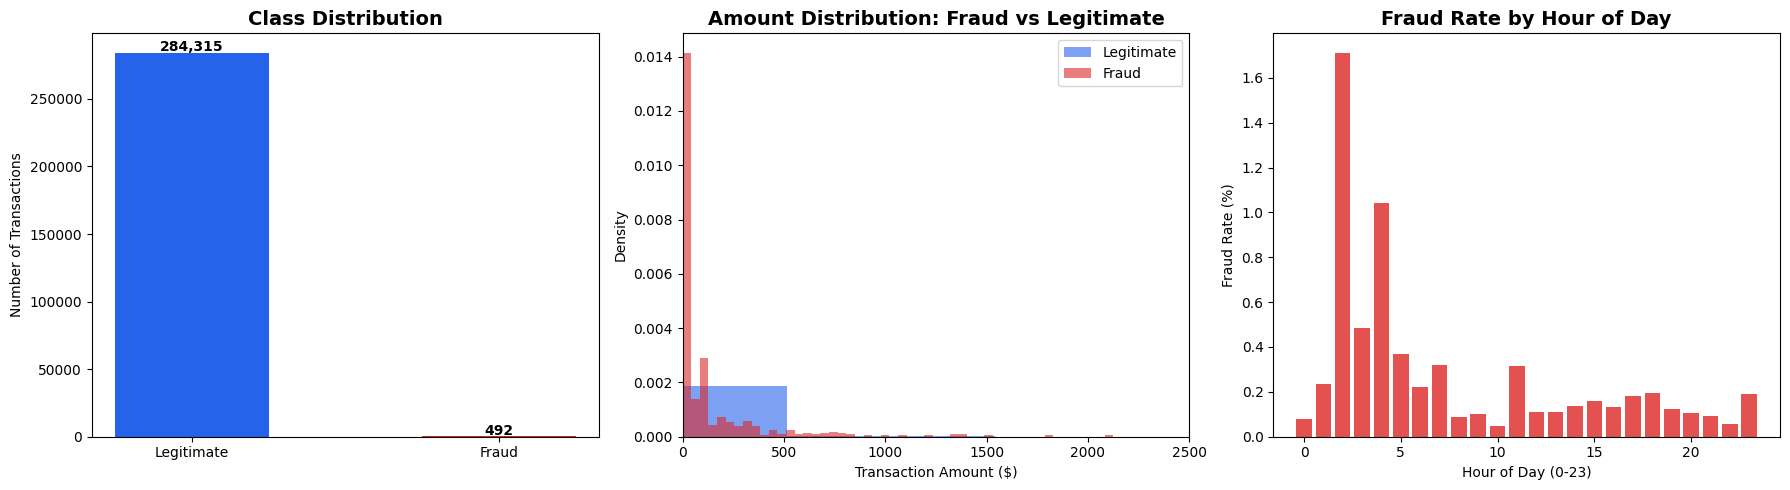

Charts saved to data/eda_charts.png


In [4]:
# Cell 3: Visualisation
# We are creating 3 charts to visually understand the data
# Chart 1: How imbalanced is the dataset?
# Chart 2: How is Amount distributed for fraud vs legitimate?
# Chart 3: Does fraud happen more at certain times?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Class imbalance ---
# This shows visually how extreme the 577:1 ratio is
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#2563EB', '#DC2626'], width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# --- Chart 2: Amount distribution ---
# Fraud transactions — what amounts are targeted?
# Log scale because legitimate amounts have extreme outliers
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']
axes[1].hist(legit_amounts, bins=50, alpha=0.6,
             color='#2563EB', label='Legitimate', density=True)
axes[1].hist(fraud_amounts, bins=50, alpha=0.6,
             color='#DC2626', label='Fraud', density=True)
axes[1].set_title('Amount Distribution: Fraud vs Legitimate',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(0, 2500)

# --- Chart 3: Fraud by hour of day ---
# Time column is seconds since first transaction
# Dividing by 3600 gives hours, mod 24 gives hour of day (0-23)
# This tells us: do fraudsters prefer certain hours?
df['hour'] = (df['Time'] / 3600 % 24).astype(int)
fraud_by_hour = df[df['Class'] == 1].groupby('hour').size()
legit_by_hour = df[df['Class'] == 0].groupby('hour').size()
fraud_rate_by_hour = fraud_by_hour / (fraud_by_hour + legit_by_hour) * 100
axes[2].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
            color='#DC2626', alpha=0.8)
axes[2].set_title('Fraud Rate by Hour of Day',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hour of Day (0-23)')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to data/eda_charts.png")

In [5]:
# Cell 4: Feature engineering and final feature list
# This cell answers: exactly what columns will our model learn from?

# Step 1: Create hour feature from Time
# Time is raw seconds since first transaction
# hour of day is more meaningful — patterns repeat daily
df['hour'] = (df['Time'] / 3600 % 24).astype(int)

# Step 2: Scale Amount
# V1-V28 are already scaled by PCA — they range from roughly -5 to +5
# Amount ranges from $0 to $25,691 — completely different scale
# StandardScaler transforms Amount to mean=0, std=1
# This prevents the model giving Amount unfair weight
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Step 3: Define final feature columns
# We drop: Time (replaced by hour), Amount (replaced by amount_scaled), Class (target)
feature_columns = [col for col in df.columns
                   if col not in ['Time', 'Amount', 'Class']]

print("=== FINAL FEATURE LIST ===")
print(f"Total features: {len(feature_columns)}")
print()
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2}. {col}")

print()
print("=== TARGET COLUMN ===")
print("  Class: 0 = Legitimate, 1 = Fraud")

print()
print("=== SCALE POSITION WEIGHT ===")
# This is the key to handling class imbalance in LightGBM
# It tells LightGBM: treat each fraud case as if it appeared
# this many times in the training data
legit_count = (df['Class'] == 0).sum()
fraud_count = df['Class'].sum()
scale_weight = legit_count / fraud_count
print(f"Legitimate: {legit_count:,}")
print(f"Fraud: {fraud_count:,}")
print(f"scale_pos_weight = {legit_count:,} / {fraud_count:,} = {scale_weight:.1f}")
print()
print("This tells LightGBM: each fraud case counts as much as",
      f"{scale_weight:.0f} legitimate cases")
print("This directly compensates for the 577:1 imbalance")

=== FINAL FEATURE LIST ===
Total features: 30

   1. V1
   2. V2
   3. V3
   4. V4
   5. V5
   6. V6
   7. V7
   8. V8
   9. V9
  10. V10
  11. V11
  12. V12
  13. V13
  14. V14
  15. V15
  16. V16
  17. V17
  18. V18
  19. V19
  20. V20
  21. V21
  22. V22
  23. V23
  24. V24
  25. V25
  26. V26
  27. V27
  28. V28
  29. hour
  30. amount_scaled

=== TARGET COLUMN ===
  Class: 0 = Legitimate, 1 = Fraud

=== SCALE POSITION WEIGHT ===
Legitimate: 284,315
Fraud: 492
scale_pos_weight = 284,315 / 492 = 577.9

This tells LightGBM: each fraud case counts as much as 578 legitimate cases
This directly compensates for the 577:1 imbalance


# EDA Summary — decisions made from data analysis
# This documents WHY we made each choice in model.py
# A real developer always documents their reasoning

 DATASET FACTS:
--------------
- 284,807 transactions over 48 hours
- 492 fraud cases (0.17%) extreme imbalance
- 30 features after engineering
- No missing values no cleaning needed
- All features are numerical no encoding needed

 FEATURE DECISIONS:
------------------
- DROP Time: raw seconds, not meaningful
- DROP Amount: replaced by scaled version
- KEEP V1-V28: PCA-transformed bank features, use as-is
- CREATE hour: (Time / 3600) % 24 fraud peaks at 0-5am
- CREATE amount_scaled: StandardScaler prevents scale bias

 MODEL DECISIONS:
----------------
- Algorithm: LightGBM
  Reason: fastest on tabular data, handles imbalance natively

- scale_pos_weight: 577.9
  Reason: compensates for 577:1 class imbalance
  Without this: model predicts 'not fraud' always

- Evaluation metric: AUC-ROC + F1 score
  Reason: accuracy is misleading on imbalanced data
  A 99.83% accurate model that misses all fraud is useless
  AUC-ROC measures how well fraud is ranked above legitimate

- Train/Test split: 80% train, 20% test
  Reason: standard split, enough test data to evaluate rare fraud cases

 WHAT GOES INTO model.py:
-------------------------
- Load and preprocess data using decisions above
- Train LightGBM with scale_pos_weight=577.9
- Evaluate with AUC-ROC and classification report
- Save trained model to models/fraud_model.pkl
- Save scaler to models/scaler.pkl
  (scaler must be saved API uses it to scale Amount at prediction time)